In [18]:
import os
import pathlib

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [34]:
DAPT2020_PATH = pathlib.Path('../datasets/cherry-picked/dapt2020-original')
PLAYGROUND_PATH = pathlib.Path('playground')

np.seterr(divide='ignore', invalid='ignore')

sns.set_theme()
sns.set_style('ticks')

pd.options.display.max_columns = None

plt.rcParams['figure.figsize'] = (12, 6)

In [20]:

dapt2020_flows = pd.DataFrame()

for filename in os.listdir(DAPT2020_PATH):
    if filename.endswith('.csv'):
        csv_path = DAPT2020_PATH / filename
        interface_flows = pd.read_csv(csv_path, header=0, low_memory=False, delimiter=',')
        
        # Trata o caso em que o arquivo CSV não possui um cabeçalho, atribuindo
        # os nomes das colunas com base nos CSVs anteriores
        if 'Flow ID' not in interface_flows.columns:
            interface_flows = pd.read_csv(csv_path, header=None, low_memory=False)
            interface_flows.columns = dapt2020_flows.columns[:-1]

        interface_flows['File'] = filename

        dapt2020_flows = pd.concat([dapt2020_flows, interface_flows], ignore_index=True)

dapt2020_flows['Timestamp'] = pd.to_datetime(dapt2020_flows['Timestamp'], format='%d/%m/%Y %I:%M:%S %p')
dapt2020_flows['Activity'] = dapt2020_flows['Activity'].replace('BENIGN', 'Normal')
dapt2020_flows['Stage'] = dapt2020_flows['Stage'].replace('BENIGN', 'Benign')
dapt2020_flows['Day'] = dapt2020_flows['Timestamp'].dt.day_name()
dapt2020_flows.sort_values(by='Timestamp', kind='mergesort', inplace=True, ignore_index=True)

In [21]:
dapt2020_flows.columns

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets',
       'Total Length of Fwd Packet', 'Total Length of Bwd Packet',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Len

In [22]:
for column in dapt2020_flows.columns:
    print(f'{column}: {dapt2020_flows[column].dtype}')

Flow ID: str
Src IP: str
Src Port: int64
Dst IP: str
Dst Port: int64
Protocol: int64
Timestamp: datetime64[us]
Flow Duration: int64
Total Fwd Packet: int64
Total Bwd packets: int64
Total Length of Fwd Packet: float64
Total Length of Bwd Packet: float64
Fwd Packet Length Max: float64
Fwd Packet Length Min: float64
Fwd Packet Length Mean: float64
Fwd Packet Length Std: float64
Bwd Packet Length Max: float64
Bwd Packet Length Min: float64
Bwd Packet Length Mean: float64
Bwd Packet Length Std: float64
Flow Bytes/s: float64
Flow Packets/s: float64
Flow IAT Mean: float64
Flow IAT Std: float64
Flow IAT Max: float64
Flow IAT Min: float64
Fwd IAT Total: float64
Fwd IAT Mean: float64
Fwd IAT Std: float64
Fwd IAT Max: float64
Fwd IAT Min: float64
Bwd IAT Total: float64
Bwd IAT Mean: float64
Bwd IAT Std: float64
Bwd IAT Max: float64
Bwd IAT Min: float64
Fwd PSH Flags: int64
Bwd PSH Flags: int64
Fwd URG Flags: int64
Bwd URG Flags: int64
Fwd Header Length: int64
Bwd Header Length: int64
Fwd Packets/

In [23]:
dapt2020_flows.info()

<class 'pandas.DataFrame'>
RangeIndex: 86691 entries, 0 to 86690
Data columns (total 87 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Flow ID                     86691 non-null  str           
 1   Src IP                      86691 non-null  str           
 2   Src Port                    86691 non-null  int64         
 3   Dst IP                      86691 non-null  str           
 4   Dst Port                    86691 non-null  int64         
 5   Protocol                    86691 non-null  int64         
 6   Timestamp                   86691 non-null  datetime64[us]
 7   Flow Duration               86691 non-null  int64         
 8   Total Fwd Packet            86691 non-null  int64         
 9   Total Bwd packets           86691 non-null  int64         
 10  Total Length of Fwd Packet  86691 non-null  float64       
 11  Total Length of Bwd Packet  86691 non-null  float64       
 12  F

In [24]:
dapt2020_flows.describe()

,Src Port,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,86691.000000,86691.000000,86691.000000,86691,8.669100e+04,86691.000000,86691.000000,8.669100e+04,8.669100e+04,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,8.669100e+04,86691.000000,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,86691.0,86691.000000,86691.0,86691.0,8.669100e+04,8.669100e+04,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,8.669100e+04,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.0,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.000000,86691.0,86691.0,86691.0,86691.0,86691.0,86691.0,86691.000000,8.669100e+04,86691.000000,8.669100e+04,86691.0,86691.000000,86691.000000,86691.0,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04,8.669100e+04
mean,39742.167065,8125.916312,9.048010,2019-07-17 10:57:42.817466,2.151839e+07,737.011593,419.273039,5.993707e+04,4.163274e+04,230.462666,21.904604,83.924884,76.838640,660.348098,24.413780,197.319854,172.522325,5.822969e+04,14163.176764,2.017142e+06,1.055916e+06,4.975480e+06,1.461385e+06,1.921852e+07,1.906964e+06,1.166674e+06,4.388332e+06,1.094925e+06,8.050811e+06,6.435367e+05,8.796742e+05,2.492519e+06,2.929171e+04,0.0,0.077874,0.0,0.0,2.322782e+04,1.337211e+04,2763.594188,11399.582576,22.009990,730.721459,150.124873,182.418136,7.315897e+05,0.135735,0.312778,0.023024,0.077874,0.305822,0.0,0.000104,0.000104,1.181380,159.336664,83.924884,197.319854,0.0,0.0,0.0,0.0,0.0,0.0,737.011593,5.993707e+04,419.273039,4.163274e+04,-1.0,928.134247,696.410977,0.0,5.867621e+05,2.442647e+05,8.610962e+05,3.501332e+05,3.992249e+06,6.451986e+05,4.704861e+06,3.365484e+06
min,0.000000,0.000000,0.000000,2019-07-15 13:45:37,4.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.025000,4.000000e+00,0.000000e+00,4.000000e+00,-9.192650e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-9.192650e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.008333,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000e+00,1.000000,0.000000e+00,-1.0,-1.000000,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,36166.500000,53.000000,6.000000,2019-07-16 13:59:24,3.800000e+02,1.00

In [25]:
fwd_columns = ['Src IP', 'Src Port', 'Total Fwd Packet', 'FWD Init Win Bytes']
bwd_columns = ['Dst IP', 'Dst Port', 'Total Bwd packets', 'Bwd Init Win Bytes']

# # Essas colunas não possuem correspondentes:
# # - 'Fwd Act Data Pkts'
# # - 'Fwd Seg Size Min'

corrected_dapt2020_flows = dapt2020_flows.copy()

for column in corrected_dapt2020_flows.columns:
     if 'fwd' not in column.lower():
         continue

     bwd_column = column.replace('Fwd', 'Bwd')
     bwd_column = bwd_column.replace('FWD', 'BWD')
    
     if bwd_column in corrected_dapt2020_flows.columns:
         fwd_columns.append(column)
         bwd_columns.append(bwd_column)

# # mask = [not fid.startswith(ip) for fid, ip in zip(corrected_dapt2020_flows['Flow ID'], corrected_dapt2020_flows['Src IP'])]


first_src = corrected_dapt2020_flows.groupby('Flow ID')['Src IP'].transform('first')
mask = corrected_dapt2020_flows['Src IP'] != first_src

# # print(sum(mask))


corrected_dapt2020_flows.loc[mask, fwd_columns + bwd_columns] = corrected_dapt2020_flows.loc[mask, bwd_columns + fwd_columns].values

In [26]:
len(corrected_dapt2020_flows)

86691

In [27]:
len(corrected_dapt2020_flows['Flow ID'].unique())

40244

In [28]:
len(corrected_dapt2020_flows['Protocol'].unique())

3

In [29]:
print('Stage Distribution:')
for stage in corrected_dapt2020_flows['Stage'].unique():
    print(f"  {stage}: {len(corrected_dapt2020_flows[corrected_dapt2020_flows['Stage'] == stage])}")
    
    for activity in corrected_dapt2020_flows[corrected_dapt2020_flows['Stage'] == stage]['Activity'].unique():
        print(f"    {activity}: {len(corrected_dapt2020_flows[(corrected_dapt2020_flows['Stage'] == stage) & (corrected_dapt2020_flows['Activity'] == activity)])}")

Stage Distribution:
  Benign: 63712
    Normal: 63712
  Reconnaissance: 11909
    Network Scan: 7614
    Account Discovery: 124
    Directory Bruteforce: 1503
    Web Vulnerability Scan: 2574
    Account Bruteforce: 94
  Establish Foothold: 8604
    SQL Injection: 55
    Directory Bruteforce: 8467
    Account Bruteforce: 47
    Account Discovery: 12
    Network Scan: 2
    CSRF: 7
    Malware Download: 2
    Command Injection: 12
  Lateral Movement: 2451
    Account Discovery: 2272
    SQL Injection: 29
    Network Scan: 117
    Privilege Escalation: 13
    Backdoor: 20
  Data Exfiltration: 15
    Data Exfiltration: 6
    Network Scan: 9


In [30]:
print('Feature Metrics:')
for feature in corrected_dapt2020_flows.columns:
    if not pd.api.types.is_numeric_dtype(corrected_dapt2020_flows[feature]):
        continue

    print(f"  {feature}:")
    for stage in corrected_dapt2020_flows['Stage'].unique():
        stage_data = corrected_dapt2020_flows[corrected_dapt2020_flows['Stage'] == stage][feature]
        print(f"    {stage}: (Min: {stage_data.min():.2f}, Max: {stage_data.max():.2f}, Mean: {stage_data.mean():.2f}, Median: {stage_data.median():.2f}, Std: {stage_data.std():.2f})")

Feature Metrics:
  Src Port:
    Benign: (Min: 0.00, Max: 65475.00, Mean: 41249.13, Median: 46688.50, Std: 17144.87)
    Reconnaissance: (Min: 7606.00, Max: 64932.00, Mean: 47687.80, Median: 47640.00, Std: 4813.01)
    Establish Foothold: (Min: 13898.00, Max: 64271.00, Mean: 53971.46, Median: 54079.00, Std: 3924.25)
    Lateral Movement: (Min: 0.00, Max: 62175.00, Mean: 50130.61, Median: 55249.00, Std: 7477.90)
    Data Exfiltration: (Min: 36018.00, Max: 60674.00, Mean: 49410.93, Median: 47046.00, Std: 8302.94)
  Dst Port:
    Benign: (Min: 0.00, Max: 65390.00, Mean: 2968.10, Median: 80.00, Std: 6825.69)
    Reconnaissance: (Min: 80.00, Max: 9002.00, Mean: 6961.85, Median: 9000.00, Std: 3746.11)
    Establish Foothold: (Min: 80.00, Max: 9003.00, Mean: 8954.49, Median: 9003.00, Std: 653.99)
    Lateral Movement: (Min: 0.00, Max: 65389.00, Mean: 6629.36, Median: 3306.00, Std: 10592.80)
    Data Exfiltration: (Min: 21.00, Max: 65390.00, Mean: 31113.67, Median: 28643.00, Std: 19248.44)
  P

In [31]:
corrected_dapt2020_flows[corrected_dapt2020_flows['Flow ID'] == corrected_dapt2020_flows['Flow ID'].iloc[5]]

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage,File,Day
5,192.168.3.29-192.168.3.31-37212-9200-6,192.168.3.29,37212,192.168.3.31,9200,6,2019-07-15 13:45:39,114575395,85,73,127350.0,16611.0,4096.0,0.0,1498.235294,1601.048419,4096.0,0.0,227.547945,494.894996,1256.473958,1.379005,7.297796e+05,1.811118e+06,7004915.0,10.0,114575108.0,1.363989e+06,2.299922e+06,7004915.0,20.0,114575380.0,1.591325e+06,2.412645e+06,7007653.0,10.0,0,1,0,0,2720,2336,0.741870,0.637135,0.0,4096.0,931.176101,1392.671513,1.939534e+06,0,0,0,1,1,0,0,0,0.0,937.069620,1498.235294,227.547945,0,0,0,0,0,0,85,127350,73,16611,-1,1547,51,0,4.158885e+06,2.222295e+06,8431806.0,2011544.0,6.997096e+06,3669.091594,7004915.0,6993064.0,Normal,Benign,enp0s3-monday.pcap_Flow.csv,Monday
40,192.168.3.29-192.168.3.31-37212-9200-6,192.168.3.29,37212,192.168.3.31,9200,6,2019-07-15 13:47:40,117104782,54,53,68468.0,11850.0,4096.0,0.0,1267.925926,1393.442254,2534.0,0.0,223.584906,369.783587,685.864391,0.913712,1.104762e+06,2.238741e+06,7009992.0,13.0,117097467.0,2.209386e+06,2.762787e+06,7009992.0,158.0,117104750.0,2.252014e+06,2.772639e+06,7010679.0,454.0,0,1,0,0,1728,1696,0.461125,0.452586,0.0,4096.0,767.148148,1153.389218,1.330307e+06,0,0,0,1,1,0,0,0,0.0,774.317757,1267.925926,223.584906,0,0,0,0,0,0,54,68468,53,11850,-1,1547,28,0,3.377508e+06,1.207991e+06,7019720.0,3008400.0,6.994695e+06,6602.266178,7009992.0,6987723.0,Normal,Benign,enp0s3-monday.pcap_Flow.csv,Monday
47,192.168.3.29-192.168.3.31-37212-9200-6,192.168.3.29,37212,192.168.3.31,9200,6,2019-07-15 13:49:45,119115839,71,65,95650.0,14106.0,4096.0,0.0,1347.183099,1488.907579,2534.0,0.0,217.015385,343.461947,921.422381,1.141746,8.823395e+05,1.917095e+06,7011281.0,16.0,119108659.0,1.701552e+06,2.392366e+06,7011281.0,49.0,119115771.0,1.861184e+06,2.443131e+06,7011947.0,140.0,0,1,0,0,2272,2080,0.596058,0.545687,0.0,4096.0,819.635036,1239.759986,1.537005e+06,0,0,0,1,1,0,0,0,0.0,825.661765,1347.183099,217.015385,0,0,0,0,0,0,71,95650,65,14106,-1,1547,39,0,3.578888e+06,1.666136e+06,8021760.0,3009889.0,6.985873e+06,15731.193365,7011281.0,6960067.0,Normal,Benign,enp0s3-monday.pcap_Flow.csv,Monday
54,192.168.3.29-192.168.3.31-37212-9200-6,192.168.3.29,37212,192.168.3.31,9200,6,2019-07-15 13:51:51,119202328,88,74,129470.0,17616.0,4096.0,0.0,1471.250000,1593.367916,4096.0,0.0,238.054054,490.358826,1233.918854,1.359034,7.403871e+05,1.719319e+06,7007328.0,11.0,119202130.0,1.370139e+06,2.151034e+06,7007328.0,34.0,119202279.0,1.632908e+06,2.257442e+06,7008053.0,11.0,0,1,0,0,2816,2368,0.738241,0.620793,0.0,4096.0,927.496933,1382.570309,1.911501e+06,0,0,0,1,1,0,0,0,0.0,933.222222,1471.250000,238.054054,0,0,0,0,0,0,88,129470,74,17616,-1,1547,51,0,6.643006e+06,8.768460e+06,28065515.0,3007938.0,6.9

In [32]:
dapt2020_flows[corrected_dapt2020_flows['Flow ID'] == corrected_dapt2020_flows[corrected_dapt2020_flows['Stage'] == 'Reconnaissance']['Flow ID'].iloc[20]]

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage,File,Day
13429,192.168.3.29-206.207.50.50-9000-44176-6,206.207.50.50,44176,192.168.3.29,9000,6,2019-07-16 13:19:05,1388140,306,509,11384.0,145459.0,117.0,0.0,37.202614,53.097913,568.0,0.0,285.774067,188.148998,112987.883067,587.116573,1705.331695,4236.047061,32126.0,4.0,1374617.0,4506.940984,6850.034299,32541.0,4.0,1388140.0,2732.559055,5309.816418,32536.0,34.0,0,0,0,0,9792,16304,220.438861,366.677713,0.0,568.0,192.209559,194.047421,37654.40143,0,1,0,0,0,0,0,0,1.0,192.445399,37.202614,285.774067,0,0,0,0,0,0,306,11384,509,145459,-1,57,101,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Network Scan,Reconnaissance,enp0s3-public-tuesday.pcap_Flow.csv,Tuesday
13439,192.168.3.29-206.207.50.50-9000-44176-6,206.207.50.50,44176,192.168.3.29,9000,6,2019-07-16 13:19:06,10,1,1,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,200000.000000,10.000000,0.000000,10.0,10.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0,0,0,0,32,32,100000.000000,100000.000000,0.0,0.0,0.000000,0.000000,0.00000,0,0,0,0,1,0,0,0,1.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,1,0,1,0,-1,1444,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Network Scan,Reconnaissance,enp0s3-public-tuesday.pcap_Flow.csv,Tuesday
13455,192.168.3.29-206.207.50.50-9000-44176-6,192.168.3.29,9000,206.207.50.50,44176,6,2019-07-16 13:19:06,46,0,2,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,43478.260870,46.000000,0.000000,46.0,46.0,0.0,0.000000,0.000000,0.0,0.0,46.0,46.000000,0.000000,46.0,46.0,0,0,0,0,0,64,0.000000,43478.260870,0.0,0.0,0.000000,0.000000,0.00000,0,0,0,0,1,0,0,0,0.0,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,2,0,-1,1444,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Benign,enp0s3-public-tuesday.pcap_Flow.csv,Tuesday


In [33]:
duplicates = corrected_dapt2020_flows.groupby(['Timestamp', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol', 'Stage']).size()
print(f"Quantidade de elementos que se repetem: {(duplicates > 1).sum()}")
print(duplicates[duplicates > 1])

Quantidade de elementos que se repetem: 12685
Timestamp            Flow ID                                   Src IP        Dst IP           Src Port  Dst Port  Protocol  Stage 
2019-07-15 13:57:20  192.168.3.29-35.222.85.5-35856-80-6       192.168.3.29  35.222.85.5      35856     80        6         Benign    2
2019-07-15 14:01:00  192.168.3.30-198.143.164.251-40452-443-6  192.168.3.30  198.143.164.251  40452     443       6         Benign    2
2019-07-15 14:02:04  192.168.3.30-198.143.164.251-40478-443-6  192.168.3.30  198.143.164.251  40478     443       6         Benign    2
2019-07-15 14:02:05  192.168.3.30-198.143.164.251-40482-443-6  192.168.3.30  198.143.164.251  40482     443       6         Benign    2
                     192.168.3.30-198.143.164.251-40484-443-6  192.168.3.30  198.143.164.251  40484     443       6         Benign    2
                                                                                                                                     ..
2019-07

In [ ]:
import scipy.stats as stats

before_remove = len(corrected_dapt2020_flows)

outlier_mask = pd.Series(False, index=corrected_dapt2020_flows.index)

for col in corrected_dapt2020_flows.columns:
    if not pd.api.types.is_numeric_dtype(corrected_dapt2020_flows[col]):
        continue
    z_scores = np.abs(stats.zscore(corrected_dapt2020_flows[col]))
    outlier_mask |= (z_scores >= 4)

corrected_dapt2020_flows = corrected_dapt2020_flows[~outlier_mask]
after_remove = len(corrected_dapt2020_flows)

print(f'{before_remove - after_remove} outliers removed')

18588 outliers removed


In [16]:
duplicates = corrected_dapt2020_flows.groupby(['Timestamp', 'Flow ID', 'Src IP', 'Dst IP', 'Src Port', 'Dst Port', 'Protocol', 'Stage']).size()
print(f"Quantidade de elementos que se repetem: {(duplicates > 1).sum()}")
print(duplicates[duplicates > 1])

Quantidade de elementos que se repetem: 9534
Timestamp            Flow ID                                   Src IP        Dst IP           Src Port  Dst Port  Protocol  Stage 
2019-07-15 13:57:20  192.168.3.29-35.222.85.5-35856-80-6       192.168.3.29  35.222.85.5      35856     80        6         Benign    2
2019-07-15 14:01:00  192.168.3.30-198.143.164.251-40452-443-6  192.168.3.30  198.143.164.251  40452     443       6         Benign    2
2019-07-15 14:02:04  192.168.3.30-198.143.164.251-40478-443-6  192.168.3.30  198.143.164.251  40478     443       6         Benign    2
2019-07-15 14:02:05  192.168.3.30-198.143.164.251-40482-443-6  192.168.3.30  198.143.164.251  40482     443       6         Benign    2
                     192.168.3.30-198.143.164.251-40484-443-6  192.168.3.30  198.143.164.251  40484     443       6         Benign    2
                                                                                                                                     ..
2019-07-

In [37]:
corrected_dapt2020_flows[(corrected_dapt2020_flows['Flow ID'] == '192.168.3.29-38.27.100.197-9000-65432-6') & (corrected_dapt2020_flows['Day'] == 'Monday')]

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage,File,Day


In [40]:
corrected_dapt2020_flows[(corrected_dapt2020_flows['Flow ID'] == '192.168.3.29-192.30.253.112-40292-443-6') & (corrected_dapt2020_flows['Day'] == 'Monday')]

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Packet Length Min,Packet Length Max,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWR Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Fwd Segment Size Avg,Bwd Segment Size Avg,Fwd Bytes/Bulk Avg,Fwd Packet/Bulk Avg,Fwd Bulk Rate Avg,Bwd Bytes/Bulk Avg,Bwd Packet/Bulk Avg,Bwd Bulk Rate Avg,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,FWD Init Win Bytes,Bwd Init Win Bytes,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Activity,Stage,File,Day
12039,192.168.3.29-192.30.253.112-40292-443-6,192.168.3.29,40292,192.30.253.112,443,6,2019-07-15 21:27:03,505721,11,14,624.0,4580.0,236.0,0.0,56.727273,90.722754,3554.0,0.0,327.142857,935.642014,10290.258858,49.434372,21071.708333,39089.360117,154376.0,6.0,448979.0,44897.9,51848.807127,154376.0,36.0,440862.0,33912.461538,62649.346455,212602.0,6.0,0,0,0,0,352,464,21.751124,27.683248,0.0,3554.0,200.153846,691.518774,478198.215385,0,1,0,0,0,0,0,0,1.0,208.16,56.727273,327.142857,0,0,0,0,0,0,11,624,14,4580,-1,30,6,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Benign,enp0s3-monday.pcap_Flow.csv,Monday
12040,192.168.3.29-192.30.253.112-40292-443-6,192.168.3.29,40292,192.30.253.112,443,6,2019-07-15 21:27:03,1670,2,2,0.0,31.0,0.0,0.0,0.000000,0.000000,31.0,0.0,15.500000,21.920310,18562.874251,2395.209581,556.666667,894.030387,1589.0,38.0,1632.0,1632.0,0.000000,1632.0,1632.0,81.0,81.000000,0.000000,81.0,81.0,0,0,0,0,52,64,1197.604790,1197.604790,0.0,31.0,6.200000,13.863621,192.200000,0,0,0,0,1,0,0,0,1.0,7.75,0.000000,15.500000,0,0,0,0,0,0,2,0,2,31,0,-1,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Benign,enp0s3-monday.pcap_Flow.csv,Monday


<Axes: xlabel='Day', ylabel='Count'>

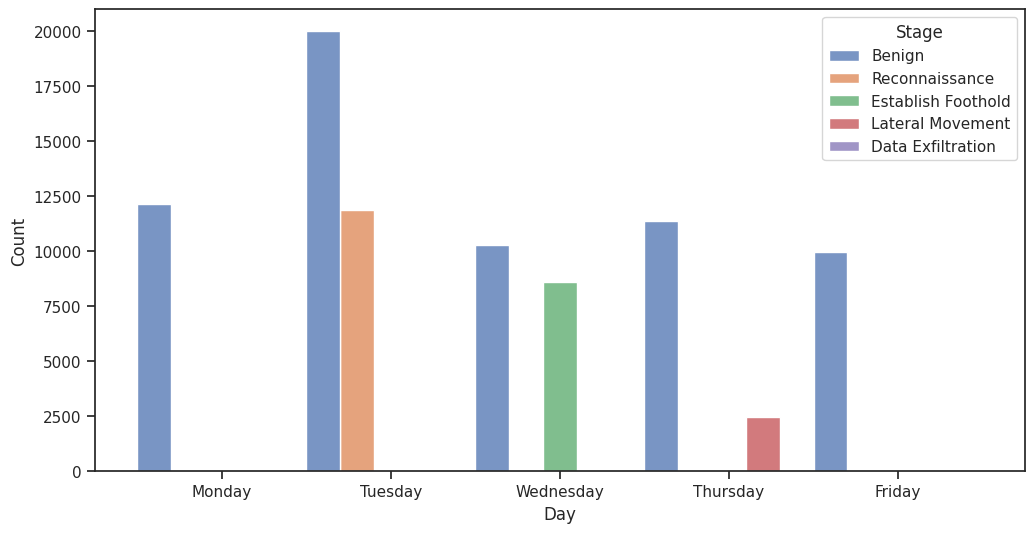

In [16]:

sns.histplot(data=corrected_dapt2020_flows, x='Day', hue='Stage', multiple='dodge')

In [17]:
values = []

for i in range(0, 100):
    if i < 20:
        values.append(0)
    elif i < 40:
        values.append(1)
    elif i < 80:
        values.append(2)
    else:
        values.append(3)
        
df = pd.DataFrame({'Value': values})

<Axes: xlabel='Value', ylabel='Count'>

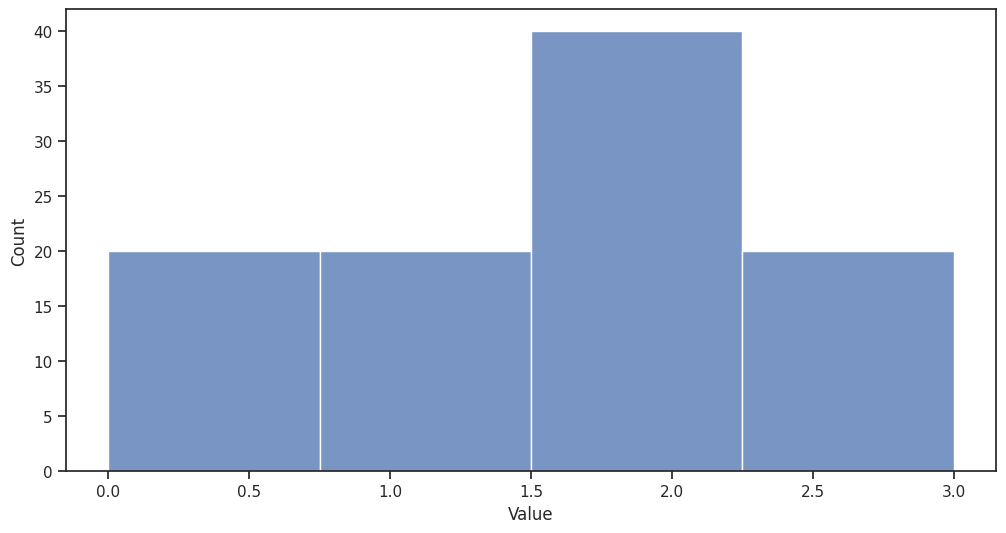

In [18]:
sns.histplot(data=df, x='Value', bins=4)

<Axes: xlabel='Value', ylabel='Density'>

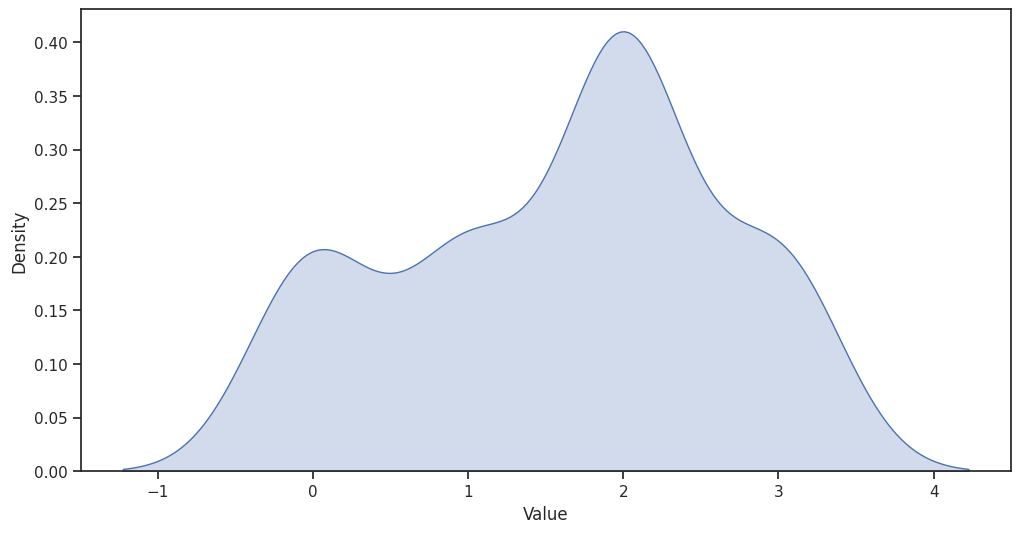

In [19]:
sns.kdeplot(data=df, x='Value', fill=True, bw_adjust=1, bw_method='scott')

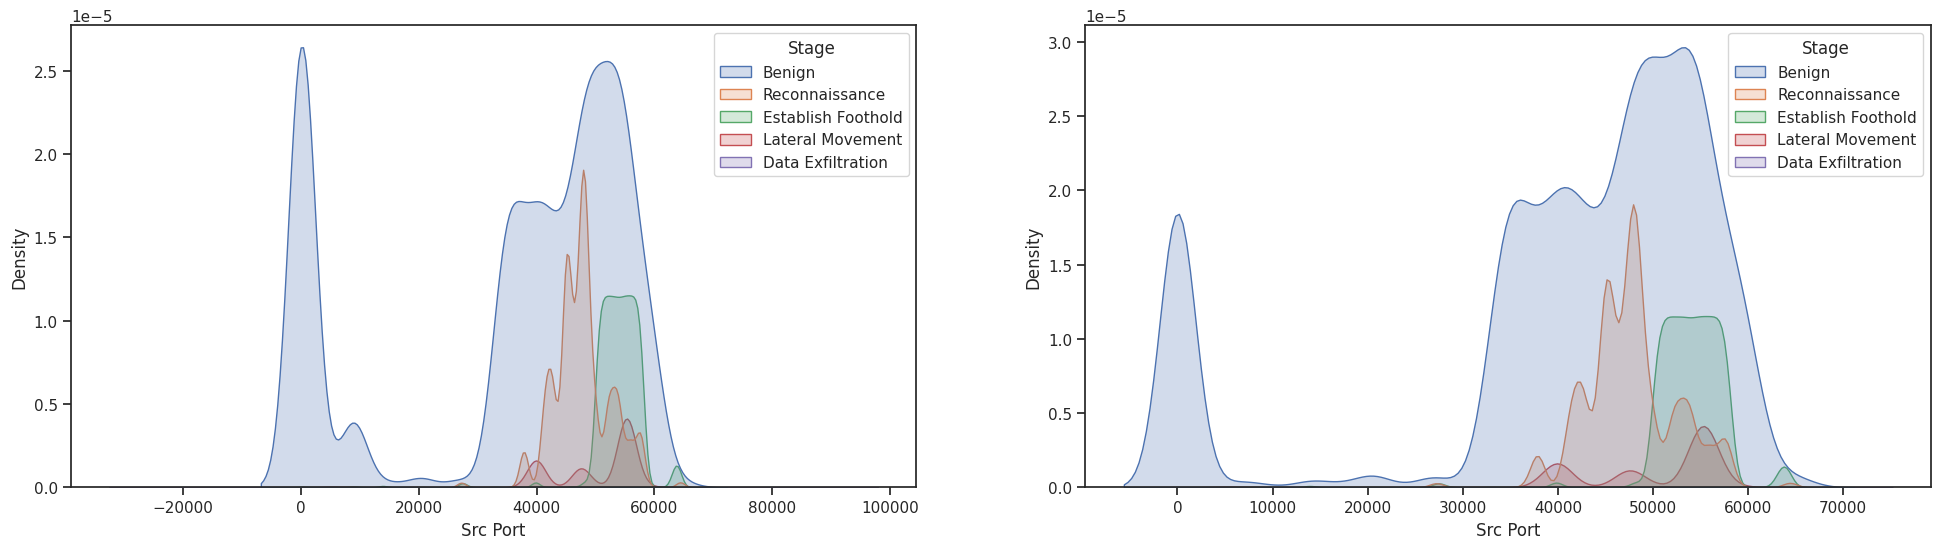

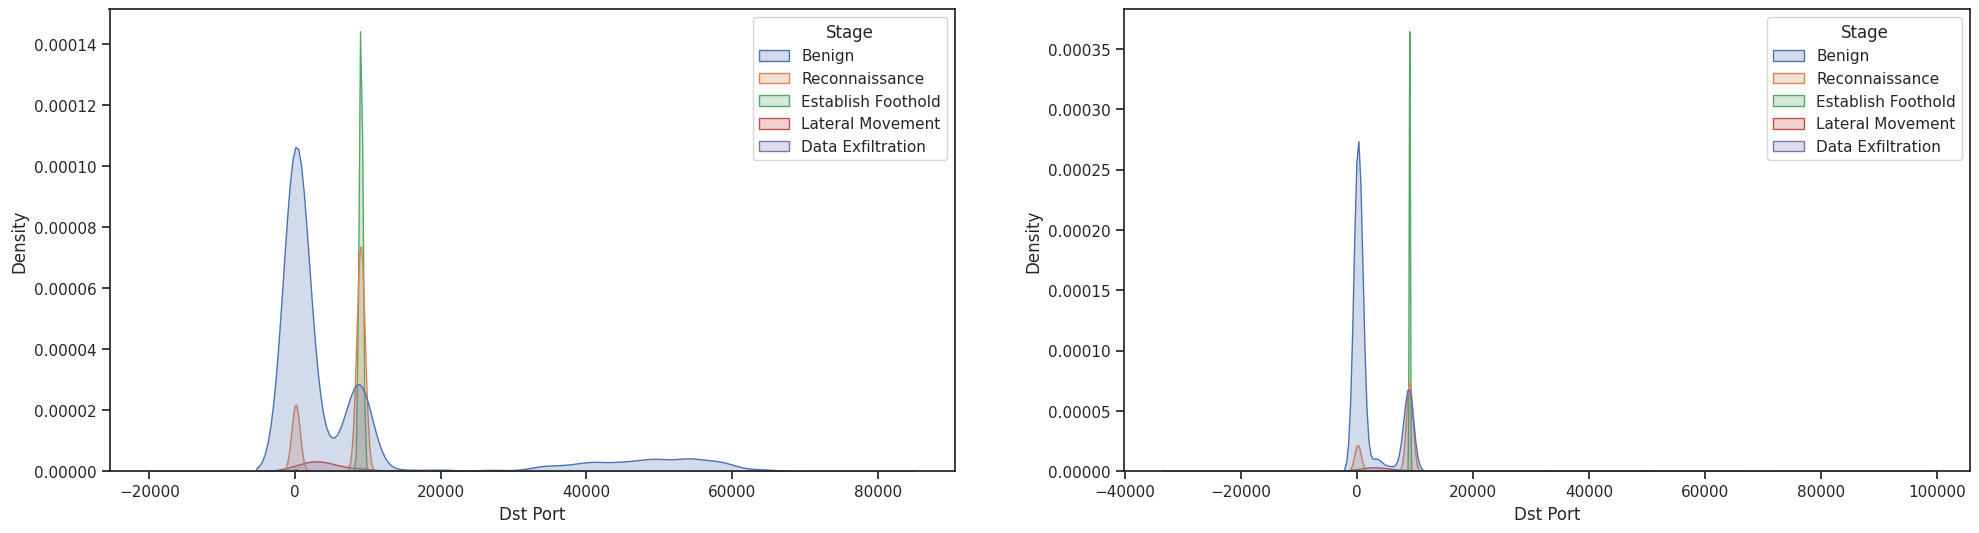

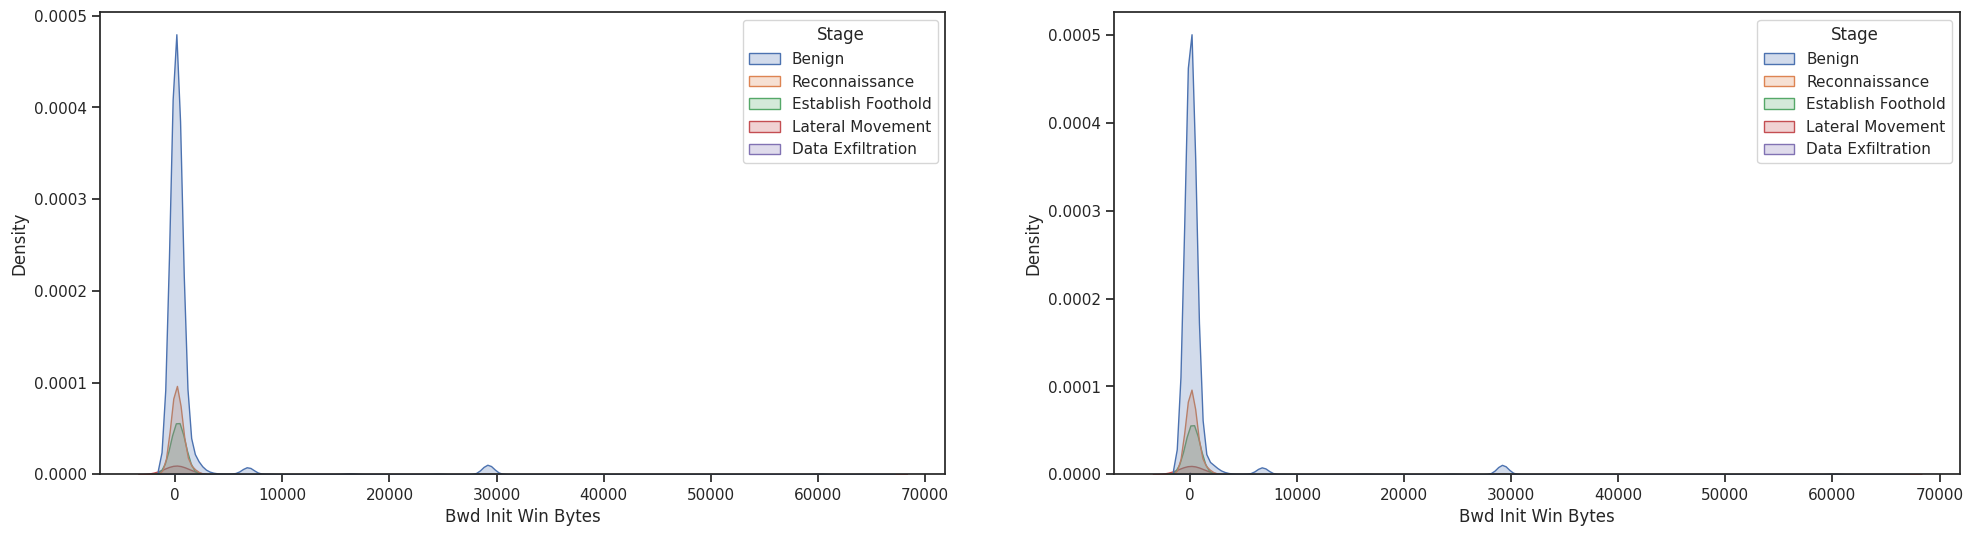

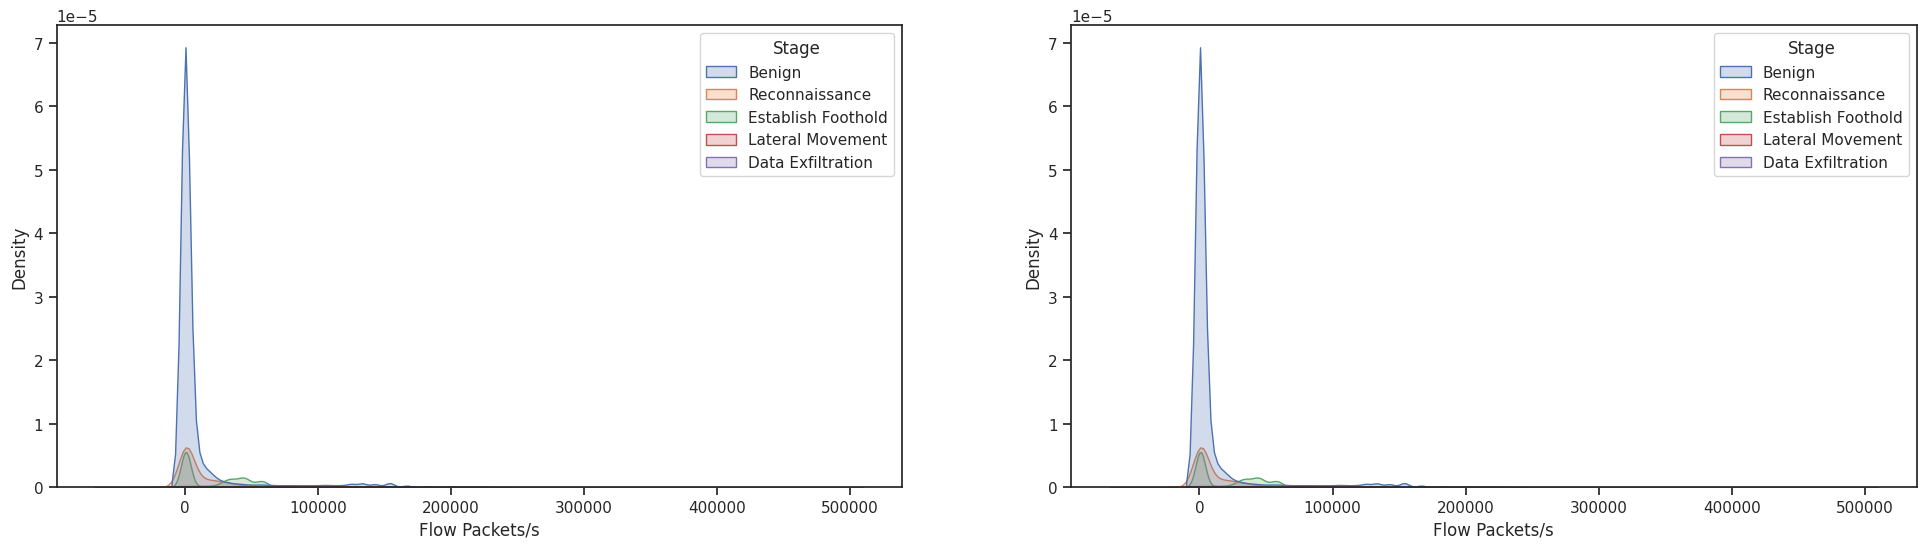

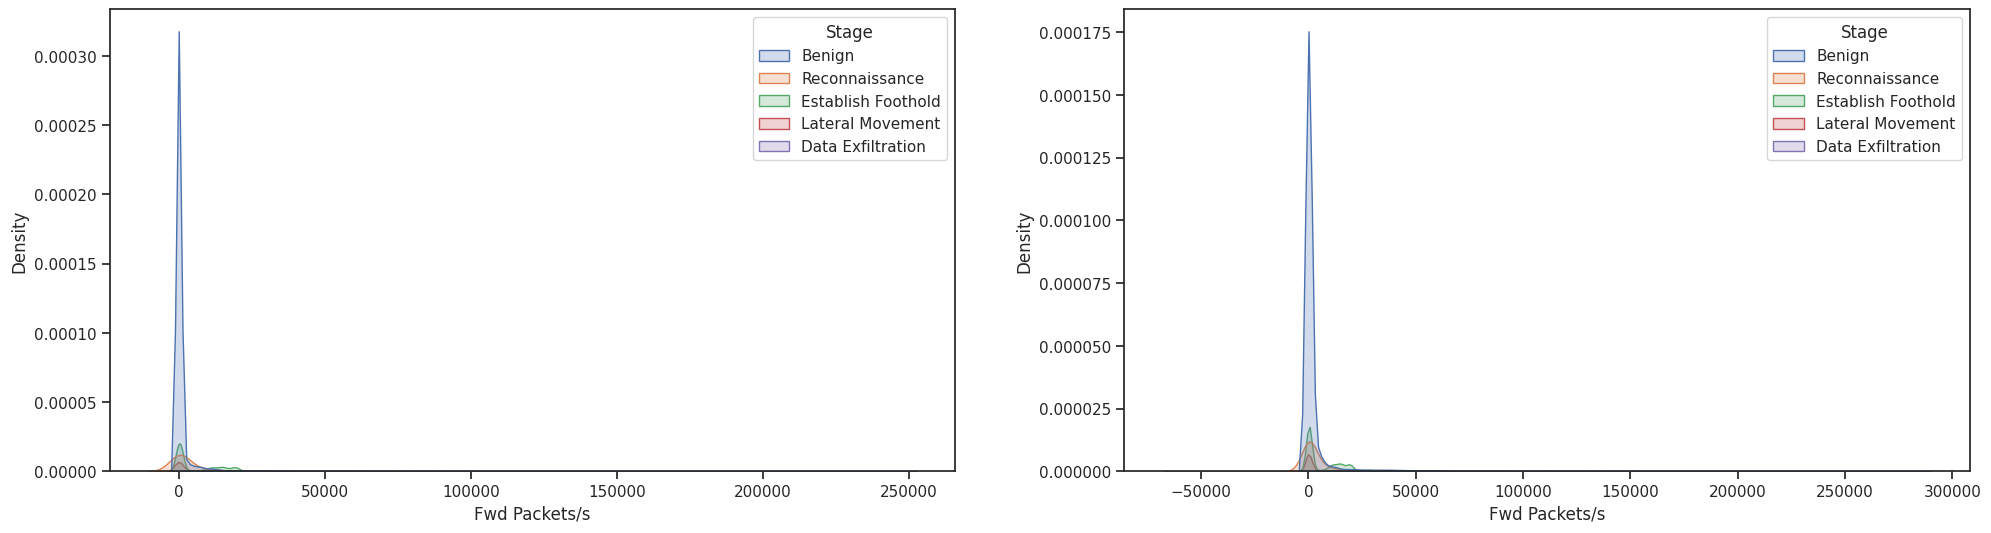

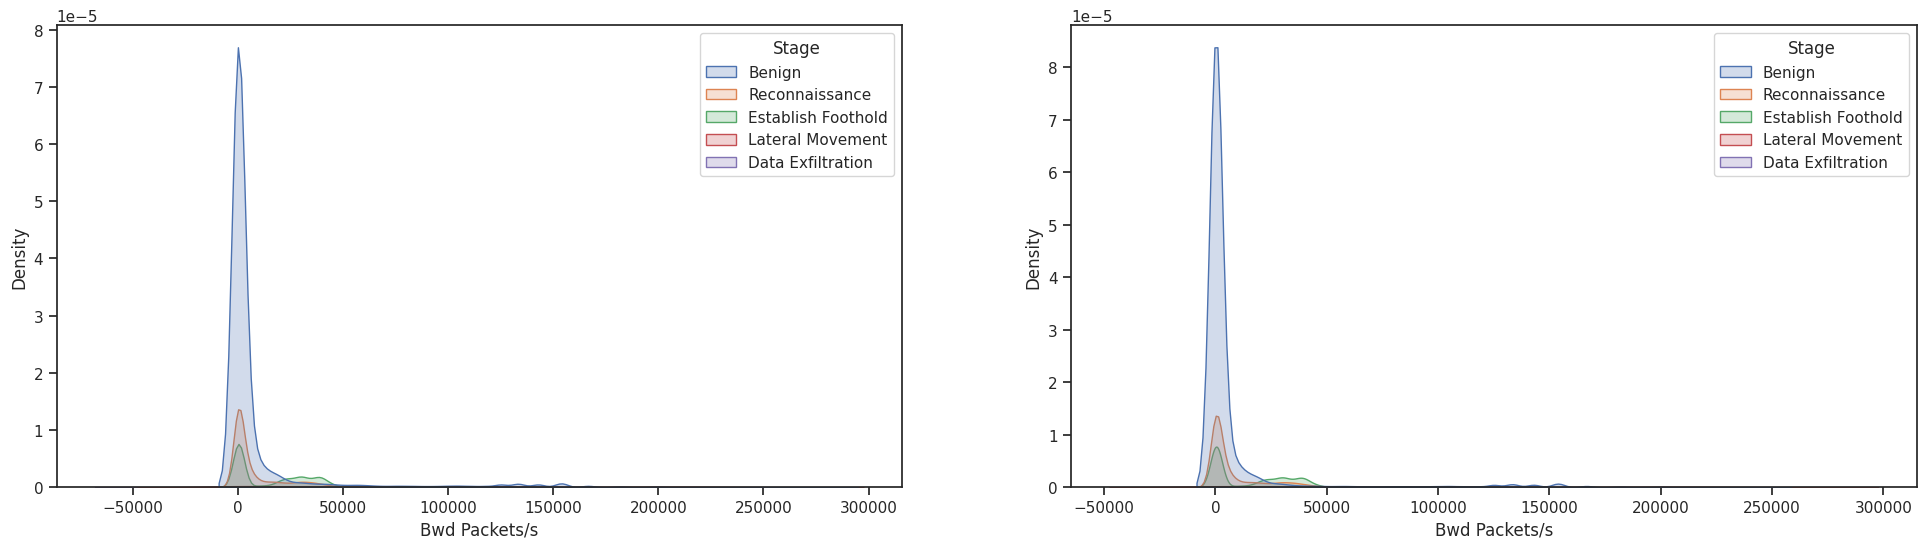

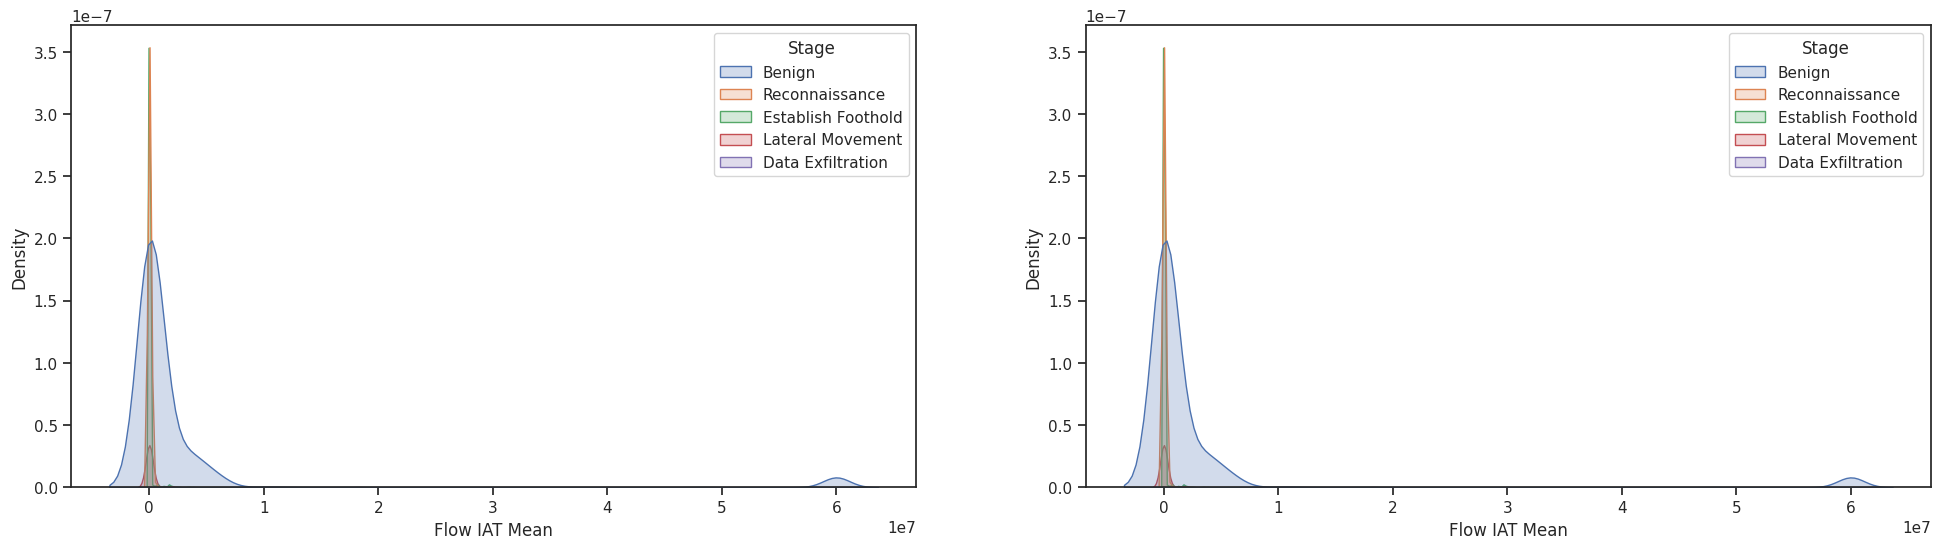

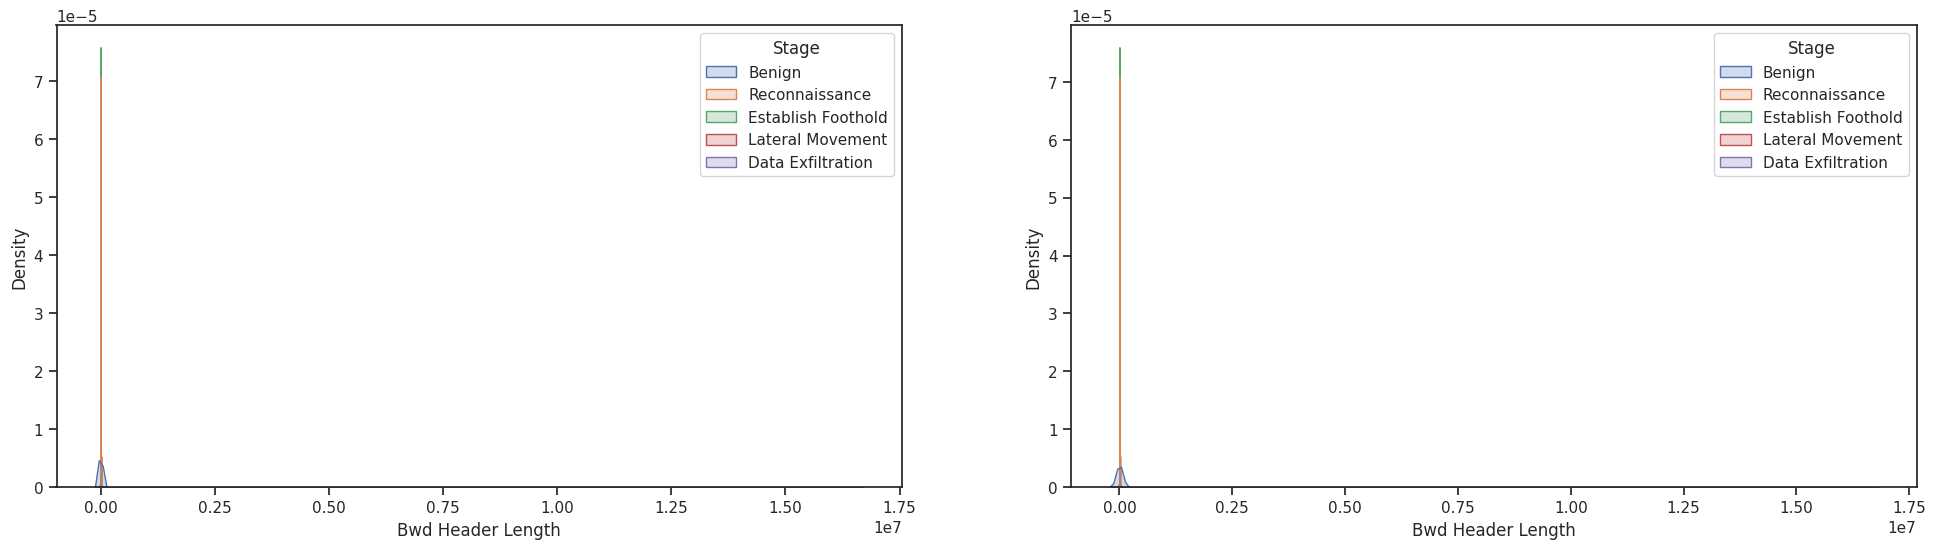

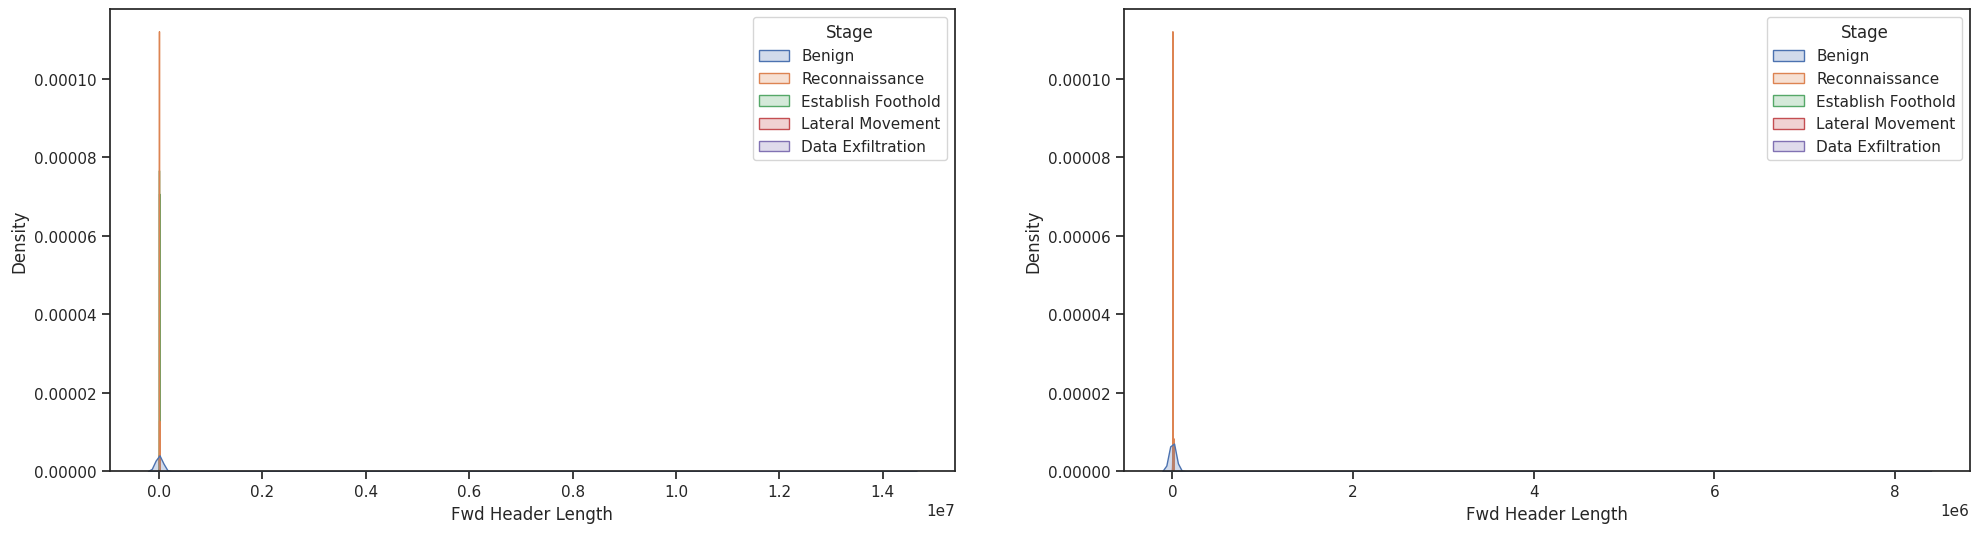

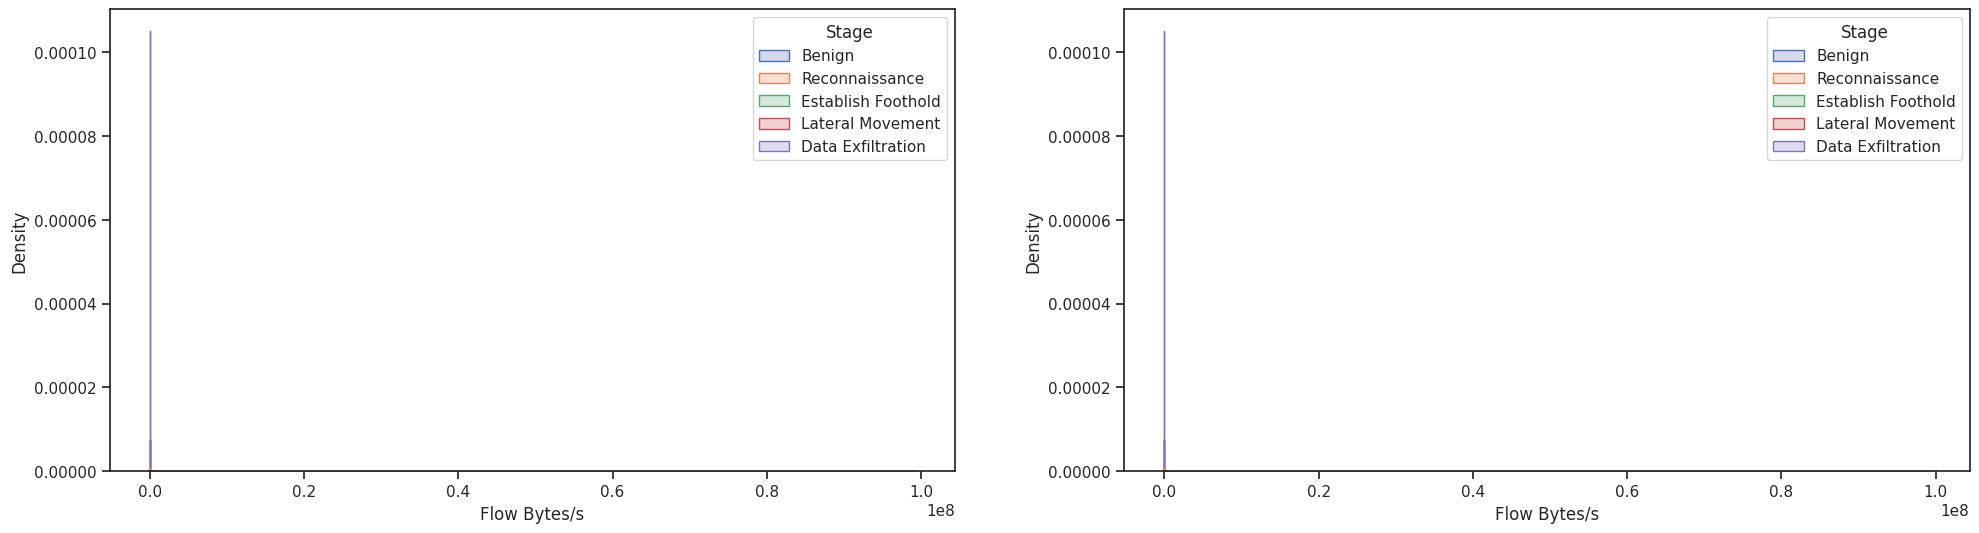

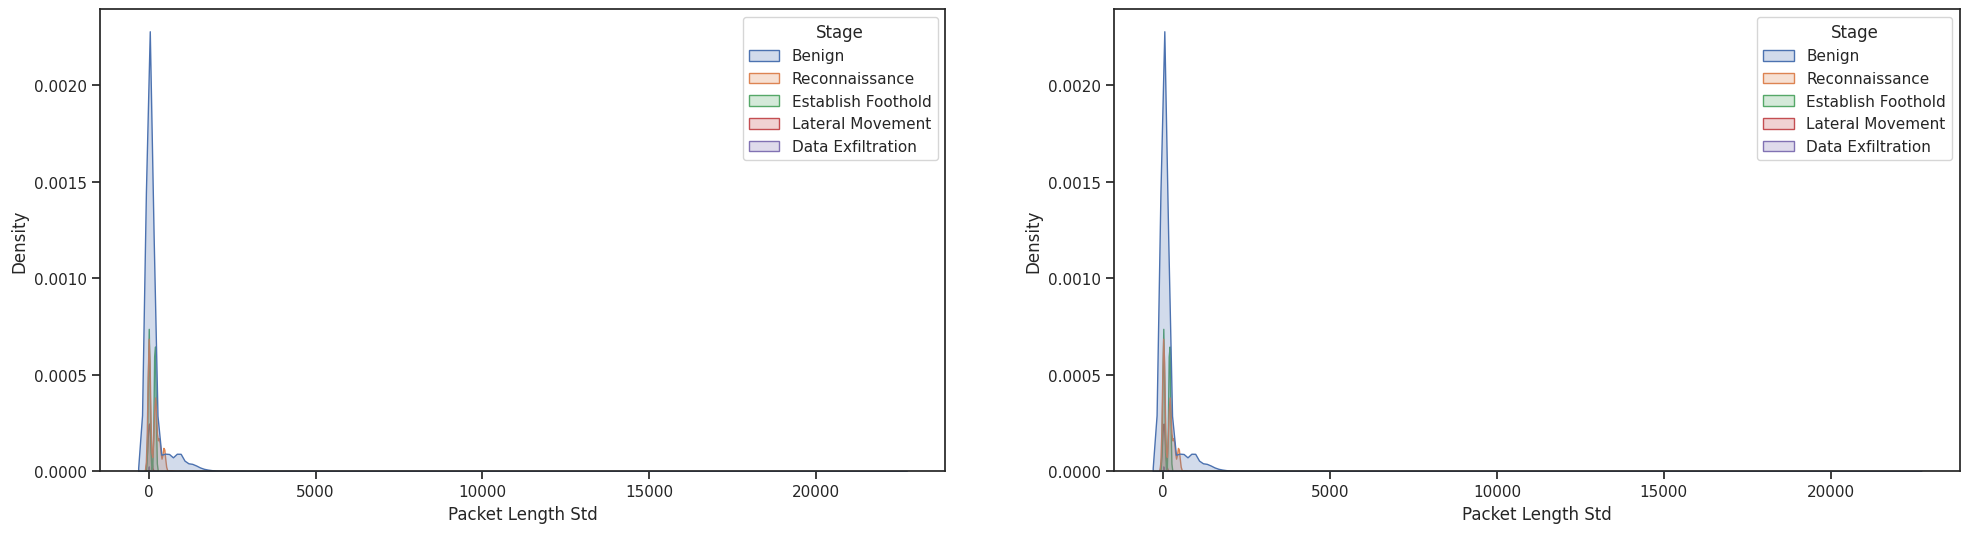

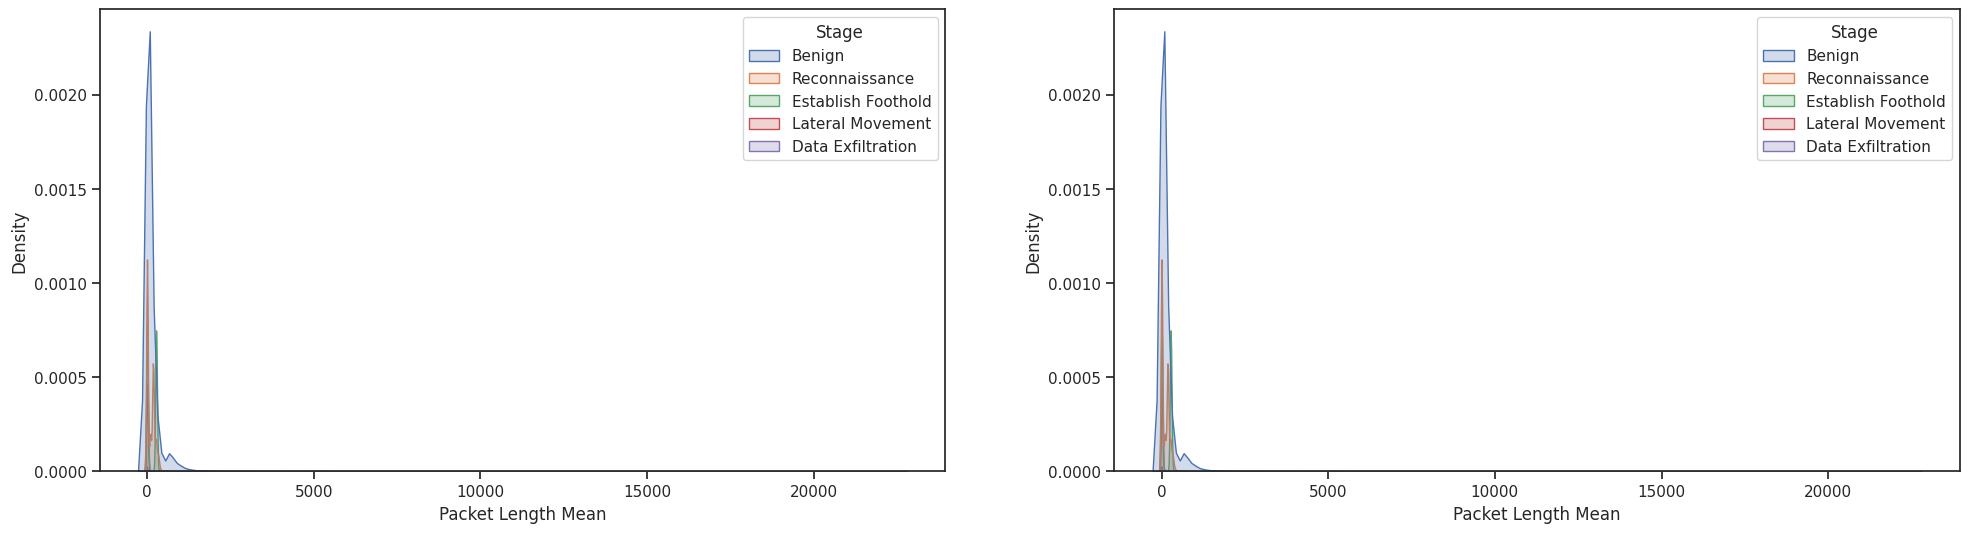

In [35]:
for feature in ['Src Port', 'Dst Port', 'Bwd Init Win Bytes', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Flow IAT Mean', 'Bwd Header Length', 'Fwd Header Length', 'Flow Bytes/s', 'Packet Length Std', 'Packet Length Mean']:
# for feature in dapt2020_flows.columns:
    if not pd.api.types.is_numeric_dtype(corrected_dapt2020_flows[feature]):
        continue
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))

    sns.kdeplot(data=dapt2020_flows, x=feature, fill=True, hue='Stage', ax=ax1)    
    sns.kdeplot(data=corrected_dapt2020_flows, x=feature, fill=True, hue='Stage', ax=ax2)
    plt.show()

In [36]:
os.makedirs(PLAYGROUND_PATH / 'rules', exist_ok=True)

for file in corrected_dapt2020_flows['File'].unique():
    selected_flows = corrected_dapt2020_flows[corrected_dapt2020_flows['File'] == file]
    selected_features = selected_flows[['Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Stage']].copy()
    # selected_features = selected_flows[['Src Port', 'Dst Port', 'Protocol', 'Stage']].copy()

    for column in selected_features.columns:
        selected_features[column] = selected_features[column].apply(lambda x: f"{column}={x}")

    selected_features = selected_features.astype(str)
    selected_features = selected_features.values.tolist()

    encoder = TransactionEncoder()
    encoded_records = encoder.fit_transform(selected_features)

    transactions = pd.DataFrame(encoded_records, columns=encoder.columns_)
    frequent_itemsets = apriori(transactions, min_support=0.001, use_colnames=True)
    
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
    rules.sort_values(by='confidence', ascending=False).to_csv(PLAYGROUND_PATH / f'rules/{file}.csv', index=False)

    filtered_rules = rules[rules['consequents'].apply(lambda x: len(x) == 1 and list(x)[0].startswith('Stage='))]
    
    print(f'{file}:')
    
    for stage in selected_flows['Stage'].unique():
        stage_rules = filtered_rules[
            (filtered_rules['confidence'] == 1.0) &
            (filtered_rules['consequents'].apply(lambda x: list(x)[0] == f'Stage={stage}'))
        ]
        
        mask = pd.Series(False, index=transactions.index)
        for _, rule in stage_rules.iterrows():
            antecedent = list(rule['antecedents'])
            mask |= transactions[antecedent].all(axis=1)
        
        covered = mask.sum()
        total = len(selected_flows[selected_flows['Stage'] == stage])
        
        
        print(f'  {stage}: {covered}/{total} ({covered/total:.2%})')

enp0s3-monday.pcap_Flow.csv:
  Benign: 8728/8728 (100.00%)
enp0s3-monday-pvt.pcap_Flow.csv:
  Benign: 3404/3404 (100.00%)
enp0s3-pvt-tuesday.pcap_Flow.csv:
  Benign: 2615/2615 (100.00%)
enp0s3-public-tuesday.pcap_Flow.csv:
  Benign: 12337/17377 (71.00%)
  Reconnaissance: 0/11865 (0.00%)
enp0s3-public-wednesday.pcap_Flow.csv:
  Benign: 8407/8855 (94.94%)
  Establish Foothold: 70/8588 (0.82%)
  Reconnaissance: 0/44 (0.00%)
enp0s3-pvt-wednesday.pcap_Flow.csv:
  Benign: 1427/1433 (99.58%)
  Establish Foothold: 0/4 (0.00%)
enp0s3-pvt-thursday.pcap_Flow.csv:
  Benign: 1748/1800 (97.11%)
  Lateral Movement: 1398/2314 (60.41%)
enp0s3-public-thursday.pcap_Flow.csv:
  Benign: 9464/9548 (99.12%)
  Lateral Movement: 0/137 (0.00%)
enp0s3-tcpdump-pvt-friday.pcap_Flow.csv:
  Benign: 2399/2612 (91.85%)
  Data Exfiltration: 0/6 (0.00%)
enp0s3-tcpdump-friday.pcap_Flow.csv:
  Benign: 7216/7340 (98.31%)
  Data Exfiltration: 0/9 (0.00%)
  Establish Foothold: 0/12 (0.00%)


8537


Covered: 8537
Total Recon: 8588
Coverage %: 0.9940614811364695
